# 최종 모델과 관리자용 위험 등급 (`03_Final_Model_Tiers`)

```
01_Baseline_Models → 02_Feature_Importance → [03_Final_Model_Tiers] → (다음) 2차 체크포인트 규칙 검증
```

## 목적

1. **최종 모델 XGBoost**와 **25일(1차) 관리자용 위험 등급 기준**을 확정한다.
2. 기준을 **왜 이 수치로 정했는지**, **왜 다른 수치를 쓰지 않았는지** 개발 세트 근거로 정리한다(디펜스용).
3. 모델·보정기·등급 기준을 고정한 뒤 **holdout(2014J)으로 한 번만** 평가한다.

## 결정 배경 (사용자 결정, 2026-09-13)

| 결정 | 내용 | 근거 |
|---|---|---|
| 최종 모델 | **XGBoost** | CV는 RandomForest와 동점(0.4055 vs 0.4061), 학기 단위 평균·최소 최고(0.360 / 0.324), 이탈 요인 해석은 RF와 거의 동일(순위 상관 0.914), 학생별 설명(SHAP) 가능, 향후 데이터 갱신·재학습 시 튜닝 부담이 작음(`02_Feature_Importance` 9절) |
| 결과 전달 대상 | **관리자(튜터·학사 담당)** | 학생에게 "위험군"을 통보하면 낙인·포기를 굳힐 위험이 있고, 관리자가 사정을 보고 대응 방식을 고르는 편이 기관 입장에서 실행 가능. 학생용 리마인더는 위험도와 무관하게 전원 발송 |
| 운영 방향 | **조기 경고 최대화 + 관리자 부담 고려** | 이탈 예방을 위해 넓게 인지하되, 관리자가 직접 대응하는 명단은 위험도 순으로 좁힌다 |
| 2단계 구조 | **25일 1차 등급 + 과목별 첫 평가 마감 2차 점검** | 25일 명단이 26–32일 이탈자의 89%를 고위험·주의로 포착. 늦은 이탈자는 2차에서 "새 평가 미제출"로 보완(별도 노트북) |

> **holdout 사용 기록**: 01에서 RandomForest의 holdout을 평가한 적이 있다. XGBoost 선택은 **개발 세트 근거(학기 단위 안정성·해석·운영성)**로 내렸고, RF holdout 수치를 보고 바꾼 것이 아니다. 이 노트북은 XGBoost holdout을 처음이자 한 번 평가한다.

## 원칙

- 등급 기준은 **실행 전에 고정**하고(3절), 민감도 분석·대안 비교는 **개발 세트 OOF**로만 한다(4·5절).
- holdout 결과는 **사후 확인**이다. 대안의 holdout 수치를 함께 보여주더라도 기준을 바꾸는 데 쓰지 않는다(8절).
- 이탈 시점(`date_unregistration`)은 **평가용으로만** 쓰고 피처로 쓰지 않는다.

## 1. 환경 설정과 데이터

In [1]:
import json
import platform
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import xgboost
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, brier_score_loss, f1_score, fbeta_score,
                             precision_recall_curve, precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

INK, INK_2, MUTED, GRID, SURFACE = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#fcfcfb'
plt.rcParams.update({'font.family': 'Malgun Gothic', 'axes.unicode_minus': False, 'figure.facecolor': SURFACE,
                     'axes.facecolor': SURFACE, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.color': GRID, 'text.color': INK_2, 'axes.titlecolor': INK,
                     'xtick.color': MUTED, 'ytick.color': MUTED, 'legend.frameon': False})
pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 60)
RANDOM_STATE, N_JOBS = 42, 4
TIER_NAMES = {1: '1 고위험', 2: '2 주의', 3: '3 관찰', 4: '4 일반'}
TIER_COLORS = {1: '#d03b3b', 2: '#eda100', 3: '#2a78d6', 4: '#c3c2b7'}


def show(frame, formats=None):
    view = frame.copy()
    for col, f in (formats or {}).items():
        if col in view.columns:
            view[col] = view[col].map(lambda v, f=f: f.format(v) if pd.notna(v) else '')
    display(view)


PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'CSV_files').exists():
    PROJECT_ROOT = (PROJECT_ROOT / '../..').resolve()
DATA_DIR, MODEL_DIR = PROJECT_ROOT / 'CSV_files' / '통합 버전', PROJECT_ROOT / 'CSV_files' / '모델링'
spec = json.load(open(DATA_DIR / 'feature_spec_n25.json', encoding='utf-8'))
summary01 = json.load(open(MODEL_DIR / 'champion_summary_n25.json', encoding='utf-8'))
saved_oof = pd.read_csv(MODEL_DIR / 'dev_oof_predictions_n25.csv')
df = pd.read_csv(DATA_DIR / 'model_df_clean_n25.csv')

TARGET, GROUP_COL, HOLDOUT_KEY = spec['target'], spec['group_col'], spec['holdout_key']
NUM, CAT = spec['numeric_features'], spec['categorical_features']
FEATURES = NUM + CAT
GRAIN = ['id_student', 'code_module', 'code_presentation']
MODEL = 'XGBoost'
PARAMS = summary01['best_params'][MODEL]
assert summary01['features_in_order'] == FEATURES

df['presentation_period'] = df['code_presentation'].str[-1]
df[TARGET] = df[TARGET].astype(int)
HOLDOUT_TERM = summary01['holdout']['term']
dev = df[df[HOLDOUT_KEY] != HOLDOUT_TERM].reset_index(drop=True)
hold = df[df[HOLDOUT_KEY] == HOLDOUT_TERM].reset_index(drop=True)
y_dev, y_hold = dev[TARGET].to_numpy(), hold[TARGET].to_numpy()
assert (saved_oof[GRAIN].to_numpy() == dev[GRAIN].to_numpy()).all()
print(f'개발 {len(dev):,}행(이탈 {y_dev.mean():.1%}) / holdout {len(hold):,}행 / 모델 {MODEL} {PARAMS}')

개발 18,504행(이탈 19.1%) / holdout 9,150행 / 모델 XGBoost {'model__learning_rate': 0.01, 'model__max_depth': 5, 'model__min_child_weight': 30}


## 2. 확률 보정 (개발 세트)

01과 같은 방식으로 XGBoost OOF 확률에 **교차 적합 sigmoid 보정**을 적용한다. 등급 기준이 **"보정된 이탈 확률"**로 정의되므로,
확률 40%가 실제로 약 40%의 이탈을 뜻해야 기준을 관리자에게 설명할 수 있다.

- 평가용: fold k의 보정기는 나머지 fold OOF로만 학습 → `cal_oof`
- holdout용: 개발 OOF 전체로 학습한 보정기 하나 → `CALIBRATOR`

In [2]:
def _logit(p):
    p = np.clip(np.asarray(p, dtype=float), 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p)).reshape(-1, 1)


CV_SPLITS = list(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE).split(dev, y_dev, groups=dev[GROUP_COL]))
raw_oof = saved_oof[f'oof_{MODEL}'].to_numpy()
cal_oof = np.zeros_like(raw_oof)
for _, va in CV_SPLITS:
    other = np.setdiff1d(np.arange(len(dev)), va)
    cal_oof[va] = LogisticRegression(C=1e6, max_iter=1000).fit(_logit(raw_oof[other]), y_dev[other]).predict_proba(_logit(raw_oof[va]))[:, 1]
CALIBRATOR = LogisticRegression(C=1e6, max_iter=1000).fit(_logit(raw_oof), y_dev)

cal_table = pd.DataFrame({
    '보정 전': {'PR-AUC': average_precision_score(y_dev, raw_oof), 'ROC-AUC': roc_auc_score(y_dev, raw_oof), 'Brier': brier_score_loss(y_dev, raw_oof), '평균 예측': raw_oof.mean()},
    '보정 후(교차 적합)': {'PR-AUC': average_precision_score(y_dev, cal_oof), 'ROC-AUC': roc_auc_score(y_dev, cal_oof), 'Brier': brier_score_loss(y_dev, cal_oof), '평균 예측': cal_oof.mean()},
}).T
cal_table['실제 이탈률'] = y_dev.mean()
display(cal_table.round(4))
print('보정기 계수(기울기, 절편):', np.round(CALIBRATOR.coef_.ravel(), 4), np.round(CALIBRATOR.intercept_, 4))

,PR-AUC,ROC-AUC,Brier,평균 예측,실제 이탈률
보정 전,0.4033,0.7278,0.2037,0.4435,0.1906
보정 후(교차 적합),0.4030,0.7277,0.1362,0.1906,0.1906


보정기 계수(기울기, 절편): [1.0921] [-1.3911]


## 3. 등급 기준 — 실행 전 고정 (A안)

| 등급 | 조건 (보정 이탈 확률 `p`) | 관리자 대응 |
|---|---|---|
| **1 고위험** | `p ≥ 0.40` | 즉시 확인·연락 |
| **2 주의** | `0.20 ≤ p < 0.40` | 모니터링(제출·접속 추이) |
| **3 관찰** | `0.13 ≤ p < 0.20` **또는** 같은 (과목, 학기) 재학생 중 위험 순위 **상위 30%** | 직접 대응 없음, 2차 체크포인트에서 재점검 |
| **4 일반** | 나머지 | 직접 대응 없음, 2차 체크포인트에서 재점검 |

**운영 조정 규칙(사전 명시)**: 관리 인력이 부족하면 **주의 등급 하한을 0.20 → 0.25**로 올린다. 빠지는 학생은 관찰 등급으로 내려가 2차 점검 대상이 된다.

**경계값 선정 논리**

| 경계 | 값 | 논리 |
|---|---|---|
| 고위험 하한 | 0.40 | 이 등급의 실제 이탈률이 전체 평균의 약 2.5배. 관리자가 연락하는 학생 두 명 중 한 명이 실제 위험 학생이 되는 수준 |
| 주의 하한 | 0.20 | 전체 평균 이탈률(19%) 수준. **"평균보다 위험한 학생은 관리자 명단에 올린다"**는 기준 |
| 관찰 하한 | 0.13 | 1~3등급 합계가 이탈자의 80%를 포함하는 선. 조기 인지 최대화 |
| 과목 내 상위 | 30% | 기준 이탈률이 낮거나 변하는 과목(GGG 등)에서 상대적 고위험 학생을 놓치지 않는 안전장치 |

순위 조건은 배포 시점에 **그 학기 재학생 전체의 25일 점수**로 계산할 수 있으므로 누수가 아니다.

In [3]:
RULE = {'high': 0.40, 'mid': 0.20, 'low': 0.13, 'module_top': 0.30}
RULE_CAPACITY = {**RULE, 'mid': 0.25}


def term_rank_pct(frame, p):
    return pd.Series(p, index=frame.index).groupby([frame['code_module'], frame['code_presentation']]).rank(pct=True, ascending=False, method='first').to_numpy()


def assign_tiers(frame, p, rule):
    pct = term_rank_pct(frame, p)
    tier = np.full(len(p), 4)
    tier[(p >= rule['low']) | (pct <= rule['module_top'])] = 3
    tier[p >= rule['mid']] = 2
    tier[p >= rule['high']] = 1
    return tier


def rule_metrics(frame, y, tier):
    out = {}
    for t in [1, 2, 3, 4]:
        m = tier == t
        out[f'{TIER_NAMES[t]} 비율'] = m.mean()
        out[f'{TIER_NAMES[t]} 이탈률'] = y[m].mean() if m.any() else np.nan
    staff = tier <= 2
    warn = tier <= 3
    out['관리자 명단(1+2)'] = staff.mean()
    out['Recall 1'] = y[tier == 1].sum() / y.sum()
    out['Recall 1+2'] = y[staff].sum() / y.sum()
    out['Recall 1~3'] = y[warn].sum() / y.sum()
    out['Precision 1'] = y[tier == 1].mean() if (tier == 1).any() else np.nan
    out['Precision 1+2'] = y[staff].mean()
    mod = frame['code_module'].to_numpy()
    rec = {m: y[(mod == m) & warn].sum() / max(y[mod == m].sum(), 1) for m in sorted(set(mod))}
    out['GGG Recall 1~3'] = rec.get('GGG', np.nan)
    out['과목 최소 Recall 1~3'] = min(rec.values())
    return out


dev_tier = assign_tiers(dev, cal_oof, RULE)
dev_summary = pd.DataFrame([rule_metrics(dev, y_dev, dev_tier)], index=['A안(개발 OOF)']).T
show(dev_summary, {'A안(개발 OOF)': '{:.3f}'})

tier_view = pd.DataFrame({'행 수': pd.Series(dev_tier).value_counts().sort_index(),
                          '이탈 수': pd.Series(y_dev).groupby(dev_tier).sum()}).rename(index=TIER_NAMES)
tier_view['비율'] = tier_view['행 수'] / len(dev)
tier_view['이탈률'] = tier_view['이탈 수'] / tier_view['행 수']
tier_view['이탈자 몫'] = tier_view['이탈 수'] / y_dev.sum()
tier_view['누적 Recall'] = tier_view['이탈자 몫'].cumsum()
floor_only = (term_rank_pct(dev, cal_oof) <= RULE['module_top']) & (cal_oof < RULE['low'])
show(tier_view, {'행 수': '{:,}', '이탈 수': '{:,}', '비율': '{:.1%}', '이탈률': '{:.1%}', '이탈자 몫': '{:.1%}', '누적 Recall': '{:.1%}'})
print(f'과목 내 상위 30% 조건으로만 관찰 등급에 들어온 학생: {floor_only.sum():,}명 (이탈 {y_dev[floor_only].sum()}명)')

,A안(개발 OOF)
1 고위험 비율,0.111
1 고위험 이탈률,0.481
2 주의 비율,0.224
2 주의 이탈률,0.281
3 관찰 비율,0.254
3 관찰 이탈률,0.148
4 일반 비율,0.412
4 일반 이탈률,0.089
관리자 명단(1+2),0.335
Recall 1,0.280


,행 수,이탈 수,비율,이탈률,이탈자 몫,누적 Recall
1 고위험,"2,050",987,11.1%,48.1%,28.0%,28.0%
2 주의,"4,148","1,167",22.4%,28.1%,33.1%,61.1%
3 관찰,"4,691",695,25.4%,14.8%,19.7%,80.8%
4 일반,"7,615",677,41.2%,8.9%,19.2%,100.0%


과목 내 상위 30% 조건으로만 관찰 등급에 들어온 학생: 464명 (이탈 31명)


**해석 (개발 세트 OOF)**

- 보정 후 평균 예측 19.1% = 실제 이탈률 19.1%, Brier 0.2037 → 0.1362. 순위(PR-AUC 0.403)는 유지된다. 등급을 **"이탈 확률 몇 % 이상"**으로 설명할 수 있다.
- **등급이 올라갈수록 실제 이탈률이 단계적으로 높아진다**: 일반 8.9% → 관찰 14.8% → 주의 28.1% → 고위험 48.1%.
- **관리자 명단(고위험+주의)은 재학생의 33.5%**이고 이탈자의 61.1%를 포함한다. 관찰까지 넓히면 58.8%로 이탈자의 80.8%를 인지한다.
- 과목 내 상위 30% 조건으로만 관찰 등급에 들어온 학생은 464명(2.5%)이다. 이 조건이 없으면 GGG 이탈자 인지율이 5.9%에 그친다(4절).

## 4. 민감도 분석 — 경계값을 하나씩 바꿨을 때 (디펜스 1)

**방법**: A안에서 한 경계만 바꾸고 나머지는 고정한 채(one-at-a-time) 개발 세트 OOF에서 핵심 지표를 비교한다.

- **관리자 명단(1+2)**: 관리자가 직접 대응하는 비율 — 업무 부담
- **Recall 1+2**: 명단이 포착하는 이탈자 비율 — 조기 대응 효과
- **Precision 1 / 1+2**: 명단에 오른 학생 중 실제 이탈 비율 — 연락의 헛수고 정도
- **Recall 1~3**: 관찰까지 포함한 인지 범위 — 2차 점검 전 인지
- **GGG Recall / 과목 최소 Recall**: 과목 간 형평 — 어떤 과목도 방치되지 않는가

,바꾼 경계,값,A안,관리자 명단(1+2),Recall 1+2,Precision 1,Precision 1+2,1 고위험 비율,3 관찰 비율,Recall 1~3,GGG Recall 1~3,과목 최소 Recall 1~3
0,high,0.30,False,0.335,0.611,0.424,0.348,0.195,0.254,0.808,0.363,0.363
1,high,0.35,False,0.335,0.611,0.456,0.348,0.155,0.254,0.808,0.363,0.363
2,high,0.40,True,0.335,0.611,0.481,0.348,0.111,0.254,0.808,0.363,0.363
3,high,0.45,False,0.335,0.611,0.528,0.348,0.066,0.254,0.808,0.363,0.363
4,high,0.50,False,0.335,0.611,0.596,0.348,0.032,0.254,0.808,0.363,0.363
5,mid,0.15,False,0.481,0.742,0.481,0.294,0.111,0.108,0.808,0.363,0.363
6,mid,0.20,True,0.335,0.611,0.481,0.348,0.111,0.254,0.808,0.363,0.363
7,mid,0.25,False,0.250,0.511,0.481,0.389,0.111,0.338,0.808,0.363,0.363
8,mid,0.30,False,0.195,0.433,0.481,0.424,0.111,0.394,0.808,0.363,0.363
9,low,0.10,False,0.335,0.611,0.481,0.348,0.111,0.397,0.893,0.363,0.363


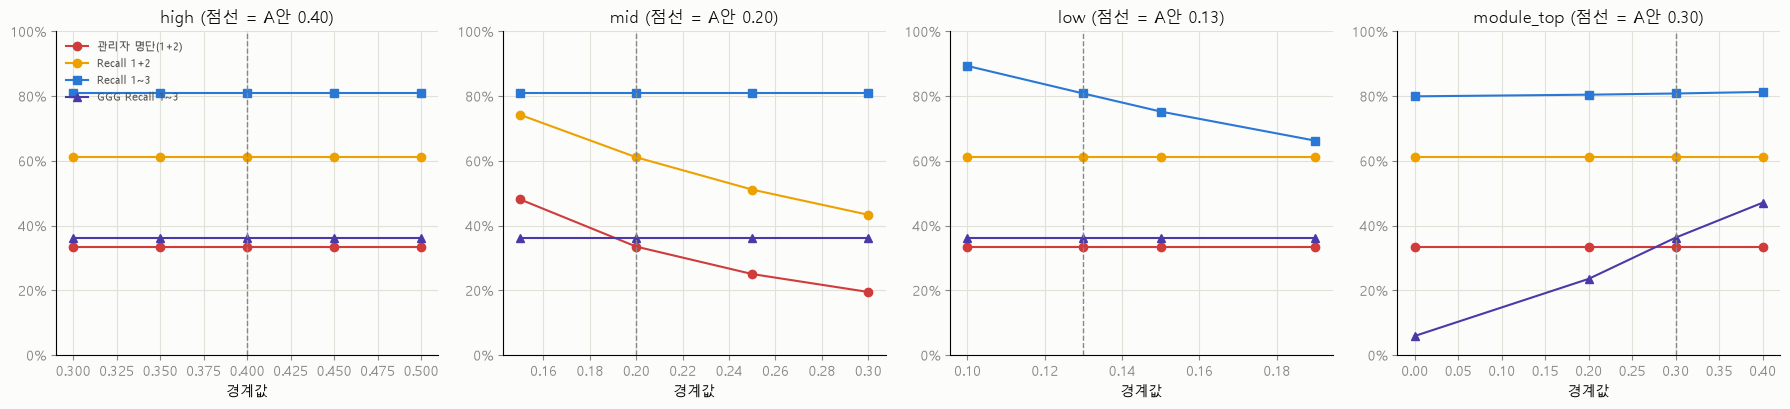

In [4]:
grid = {
    'high': [0.30, 0.35, 0.40, 0.45, 0.50],
    'mid': [0.15, 0.20, 0.25, 0.30],
    'low': [0.10, 0.13, 0.15, 0.19],
    'module_top': [0.0, 0.20, 0.30, 0.40],
}
sens_rows = []
for key, values in grid.items():
    for v in values:
        rule = {**RULE, key: v}
        if not (rule['high'] > rule['mid'] > rule['low']):
            continue
        m = rule_metrics(dev, y_dev, assign_tiers(dev, cal_oof, rule))
        sens_rows.append({'바꾼 경계': key, '값': v, 'A안': v == RULE[key], **m})
sens = pd.DataFrame(sens_rows)
cols = ['바꾼 경계', '값', 'A안', '관리자 명단(1+2)', 'Recall 1+2', 'Precision 1', 'Precision 1+2', '1 고위험 비율', '3 관찰 비율', 'Recall 1~3', 'GGG Recall 1~3', '과목 최소 Recall 1~3']
show(sens[cols], {c: '{:.3f}' for c in cols[3:]} | {'값': '{:.2f}'})

fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
for ax, key, ylab in zip(axes, grid, ['', '', '', '']):
    s = sens[sens['바꾼 경계'] == key]
    ax.plot(s['값'], s['관리자 명단(1+2)'], marker='o', color='#d03b3b', label='관리자 명단(1+2)')
    ax.plot(s['값'], s['Recall 1+2'], marker='o', color='#eda100', label='Recall 1+2')
    ax.plot(s['값'], s['Recall 1~3'], marker='s', color='#2a78d6', label='Recall 1~3')
    ax.plot(s['값'], s['GGG Recall 1~3'], marker='^', color='#4a3aa7', label='GGG Recall 1~3')
    ax.axvline(RULE[key], color=MUTED, ls='--', lw=1)
    ax.set(title=f'{key} (점선 = A안 {RULE[key]:.2f})', xlabel='경계값', ylim=(0, 1))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
axes[0].legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

**해석 — 각 경계를 A안 값으로 둔 이유**

| 경계 | 바꾸면 생기는 일 (개발 세트) | A안을 택한 이유 |
|---|---|---|
| **고위험 0.40** | 관리자 명단 전체 크기와 Recall은 **변하지 않는다**(고위험·주의를 나누기만 함). 0.30이면 고위험이 19.5%로 커지고 적중률은 42.4%, 0.50이면 3.2%로 줄고 적중률은 59.6% | "즉시 연락" 대상을 **재학생 약 10%, 두 명 중 한 명은 실제 위험** 수준으로 맞추는 균형점. 너무 낮추면 즉시 대응 부담이 두 배로 커지고, 너무 높이면 급한 학생 상당수가 모니터링으로 밀린다 |
| **주의 0.20** | 0.15면 명단 48.1%(Recall 74.2%), 0.25면 25.0%(51.1%), 0.30이면 19.5%(43.3%). **명단 크기와 Recall이 가장 크게 움직이는 경계** | 전체 평균 이탈률(19%)과 같은 선이라 "평균보다 위험하면 명단에 올린다"는 설명이 가능하다. 0.15는 명단이 재학생 절반에 가까워 관리자 과부하가 되고, 0.25 이상은 이탈자 절반을 명단 밖에 둔다. **인력 부족 시 0.25로 올리는 조정 규칙**을 둔 이유가 이 표다 |
| **관찰 0.13** | 관리자 명단에는 영향 없음. 인지 범위(1~3) Recall이 0.10이면 89.3%, 0.15면 75.2%, 0.19면 66.2% | 관찰은 관리자 직접 대응이 없어 **넓혀도 업무 부담이 늘지 않는다.** 조기 인지를 최대화하되 0.10(1~3등급 합계가 재학생의 73%로 사실상 대부분)보다는 선별력을 남긴 **Recall 80% 선** |
| **과목 내 상위 30%** | 없으면(0%) GGG 인지율 5.9%, 20%면 23.5%, 30%면 36.3%, 40%면 47.1%. 관찰 등급 비율은 22.8% → 25.4%(30%)로 +2.6%p, 관리자 명단은 변화 없음 | 전체 부담은 거의 늘리지 않고 **기준 이탈률이 낮은 과목의 방치를 막는다.** 40%는 GGG 개선이 더 크지만 과목 내 "상위"라는 의미가 약해져(10명 중 4명) 설명력이 떨어진다 |

## 5. 단일 기준 방식과 비교 (디펜스 2)

등급을 나누지 않고 **임계값 하나로 위험군을 정하는 방식**과 비교한다. 비교를 공정하게 하기 위해 각 방식의 위험군을 "관리자 명단"으로 본다.

In [5]:
def single_metrics(frame, y, flag):
    flag = flag.astype(bool)
    mod = frame['code_module'].to_numpy()
    rec = {m: y[(mod == m) & flag].sum() / max(y[mod == m].sum(), 1) for m in sorted(set(mod))}
    return {'관리자 명단': flag.mean(), 'Recall': y[flag].sum() / y.sum(), 'Precision': y[flag].mean(),
            'F1': f1_score(y, flag), '명단 밖 이탈률': y[~flag].mean(), 'GGG Recall': rec['GGG'], '과목 최소 Recall': min(rec.values())}


def best_f_threshold(y, p, beta):
    pr, rc, th = precision_recall_curve(y, p)
    pr, rc = pr[:-1], rc[:-1]
    with np.errstate(divide='ignore', invalid='ignore'):
        f = np.nan_to_num((1 + beta ** 2) * pr * rc / (beta ** 2 * pr + rc))
    return float(th[np.argmax(f)])


def recall_threshold(y, p, target):
    order = np.argsort(-p)
    k = np.searchsorted(np.cumsum(y[order]) / y.sum(), target)
    return float(p[order][k])


SINGLE = {
    'F1 최대(단일)': lambda fr, p, y: p >= best_f_threshold(y, p, 1.0),
    'F2 최대(단일)': lambda fr, p, y: p >= best_f_threshold(y, p, 2.0),
    '전역 상위 20%(단일)': lambda fr, p, y: p >= np.quantile(p, 0.80),
    'Recall 80% 선(단일)': lambda fr, p, y: p >= recall_threshold(y, p, 0.80),
    '과목 내 상위 30%만': lambda fr, p, y: term_rank_pct(fr, p) <= 0.30,
    'A안 관리자 명단(1+2)': lambda fr, p, y: assign_tiers(fr, p, RULE) <= 2,
    'A안 인지 범위(1~3)': lambda fr, p, y: assign_tiers(fr, p, RULE) <= 3,
    '인력 조정안 명단(1+2, 주의 0.25)': lambda fr, p, y: assign_tiers(fr, p, RULE_CAPACITY) <= 2,
}
# 단일 기준의 임계값은 개발 OOF에서 정해 holdout에 고정 적용한다
FIXED = {'F1 최대(단일)': best_f_threshold(y_dev, cal_oof, 1.0), 'F2 최대(단일)': best_f_threshold(y_dev, cal_oof, 2.0),
         '전역 상위 20%(단일)': float(np.quantile(cal_oof, 0.80)), 'Recall 80% 선(단일)': recall_threshold(y_dev, cal_oof, 0.80)}
print('개발 OOF에서 정한 단일 임계값:', {k: round(v, 3) for k, v in FIXED.items()})
comp_dev = pd.DataFrame({k: single_metrics(dev, y_dev, f(dev, cal_oof, y_dev)) for k, f in SINGLE.items()}).T
show(comp_dev, {c: '{:.3f}' for c in comp_dev.columns})

개발 OOF에서 정한 단일 임계값: {'F1 최대(단일)': 0.211, 'F2 최대(단일)': 0.132, '전역 상위 20%(단일)': 0.295, 'Recall 80% 선(단일)': 0.13}


,관리자 명단,Recall,Precision,F1,명단 밖 이탈률,GGG Recall,과목 최소 Recall
F1 최대(단일),0.313,0.590,0.359,0.446,0.114,0.000,0.000
F2 최대(단일),0.552,0.794,0.274,0.407,0.088,0.059,0.059
전역 상위 20%(단일),0.200,0.441,0.420,0.430,0.133,0.000,0.000
Recall 80% 선(단일),0.565,0.800,0.270,0.404,0.088,0.069,0.069
과목 내 상위 30%만,0.300,0.510,0.324,0.396,0.133,0.363,0.363
A안 관리자 명단(1+2),0.335,0.611,0.348,0.443,0.111,0.000,0.000
A안 인지 범위(1~3),0.588,0.808,0.262,0.395,0.089,0.363,0.363
"인력 조정안 명단(1+2, 주의 0.25)",0.250,0.511,0.389,0.442,0.124,0.000,0.000


**해석 — 단일 기준 대신 등급을 쓰는 이유 (개발 세트)**

| 방식 | 관리자 명단 | Recall | Precision | GGG Recall | 문제 |
|---|---:|---:|---:|---:|---|
| F1 최대 단일(0.211) | 31.3% | 59.0% | 35.9% | 0.0% | A안 명단과 크기·성능이 비슷하지만 **고위험·주의 구분이 없어** 대응 강도를 나눌 수 없고, 관찰 단계가 없어 2차 점검 대상이 정의되지 않음 |
| F2 최대 / Recall 80% 선 단일(≈0.13) | 55–57% | 79–80% | 27% | 6–7% | 인지율은 A안 인지 범위와 같지만 **재학생 절반 이상이 모두 "관리자 대응" 대상** → 과부하. GGG는 여전히 거의 방치 |
| 전역 상위 20% 단일 | 20.0% | 44.1% | 42.0% | 0.0% | 적중률은 높지만 이탈자 절반 이상을 놓침. 조기 경고 최대화 방향과 맞지 않음 |
| 과목 내 상위 30%만 | 30.0% | 51.0% | 32.4% | 36.3% | 과목 형평은 좋지만 **CCC·DDD처럼 이탈률이 높은 과목의 고위험 학생을 30%로 잘라** 전체 Recall이 낮음 |
| **A안 관리자 명단(1+2)** | 33.5% | 61.1% | 34.8% | 0.0% | — |
| **A안 인지 범위(1~3)** | 58.8% | **80.8%** | 26.2% | **36.3%** | — |

**A안의 논리 요약**: 단일 기준 하나로는 "많이 인지(Recall)"와 "관리자 부담(명단 크기)"과 "과목 형평"을 동시에 맞출 수 없다.
A안은 **인지 범위는 Recall 80% 선만큼 넓게**, **관리자 직접 대응은 F1 최대 단일 기준만큼 좁게**, **과목 형평은 과목 내 순위로 보완**하는 구조다.

## 6. 최종 모델 학습과 holdout 예측 (한 번)

개발 세트 전체로 XGBoost(01 최적 파라미터)를 학습하고, 2절 보정기와 3절 등급 기준을 **그대로** 적용한다.

In [6]:
def make_xgb():
    prep = ColumnTransformer([('num', 'passthrough', NUM), ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT)], sparse_threshold=0)
    model = XGBClassifier(n_estimators=400, subsample=0.8, colsample_bytree=0.8, scale_pos_weight=(y_dev == 0).sum() / (y_dev == 1).sum(),
                          tree_method='hist', eval_metric='aucpr', random_state=RANDOM_STATE, n_jobs=N_JOBS)
    return Pipeline([('prep', prep), ('model', model)]).set_params(**PARAMS)


final_model = make_xgb().fit(dev[FEATURES], y_dev)
hold_raw = final_model.predict_proba(hold[FEATURES])[:, 1]
hold_cal = CALIBRATOR.predict_proba(_logit(hold_raw))[:, 1]
hold_tier = assign_tiers(hold, hold_cal, RULE)

perf = pd.DataFrame({
    '개발 OOF(보정)': {'PR-AUC': average_precision_score(y_dev, cal_oof), 'ROC-AUC': roc_auc_score(y_dev, cal_oof), 'Brier': brier_score_loss(y_dev, cal_oof), '평균 예측': cal_oof.mean(), '실제 이탈률': y_dev.mean()},
    'holdout 2014J': {'PR-AUC': average_precision_score(y_hold, hold_cal), 'ROC-AUC': roc_auc_score(y_hold, hold_cal), 'Brier': brier_score_loss(y_hold, hold_cal), '평균 예측': hold_cal.mean(), '실제 이탈률': y_hold.mean()},
}).T
perf['PR-AUC / 이탈률'] = perf['PR-AUC'] / perf['실제 이탈률']
display(perf.round(4))
print(f'(참고) 01의 RandomForest holdout PR-AUC: {summary01["holdout"]["pr_auc"]:.4f} — 모델 선택에는 사용하지 않음')

,PR-AUC,ROC-AUC,Brier,평균 예측,실제 이탈률,PR-AUC / 이탈률
개발 OOF(보정),0.4030,0.7277,0.1362,0.1906,0.1906,2.115
holdout 2014J,0.3572,0.6794,0.1421,0.1799,0.1880,1.900


(참고) 01의 RandomForest holdout PR-AUC: 0.3649 — 모델 선택에는 사용하지 않음


## 7. holdout 등급 결과 — 개발 세트와 비교

**확인 포인트**: 등급별 **실제 이탈률이 개발 세트와 비슷하게 유지되는가**(등급의 의미가 새 학기에도 통하는가), 관리자 명단 규모가 예상과 비슷한가.

개발 OOF                                      holdout 2014J                                    
         행 수  이탈 수     비율    이탈률  이탈자 몫 누적 Recall           행 수 이탈 수     비율    이탈률  이탈자 몫 누적 Recall
1 고위험   2050   987  0.111  0.481  0.280     0.280           609  286  0.067  0.470  0.166     0.166
2 주의    4148  1167  0.224  0.281  0.331     0.611          2521  679  0.276  0.269  0.395     0.561
3 관찰    4691   695  0.254  0.148  0.197     0.808          1947  345  0.213  0.177  0.201     0.762
4 일반    7615   677  0.412  0.089  0.192     1.000          4073  410  0.445  0.101  0.238     1.000

,개발 OOF,holdout 2014J
1 고위험 비율,0.111,0.067
1 고위험 이탈률,0.481,0.470
2 주의 비율,0.224,0.276
2 주의 이탈률,0.281,0.269
3 관찰 비율,0.254,0.213
3 관찰 이탈률,0.148,0.177
4 일반 비율,0.412,0.445
4 일반 이탈률,0.089,0.101
관리자 명단(1+2),0.335,0.342
Recall 1,0.280,0.166


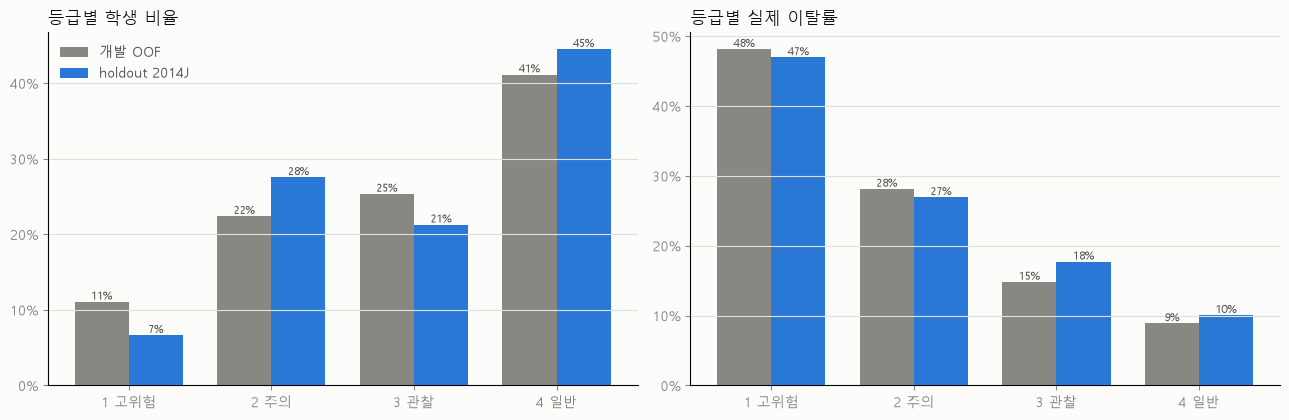

In [7]:
def tier_table(y, tier):
    t = pd.DataFrame({'행 수': pd.Series(tier).value_counts().sort_index(), '이탈 수': pd.Series(y).groupby(tier).sum()}).rename(index=TIER_NAMES)
    t['비율'] = t['행 수'] / len(y)
    t['이탈률'] = t['이탈 수'] / t['행 수']
    t['이탈자 몫'] = t['이탈 수'] / y.sum()
    t['누적 Recall'] = t['이탈자 몫'].cumsum()
    return t


both = pd.concat({'개발 OOF': tier_table(y_dev, dev_tier), 'holdout 2014J': tier_table(y_hold, hold_tier)}, axis=1)
display(both.round(3))
hold_summary = pd.DataFrame({'개발 OOF': rule_metrics(dev, y_dev, dev_tier), 'holdout 2014J': rule_metrics(hold, y_hold, hold_tier)})
show(hold_summary, {c: '{:.3f}' for c in hold_summary.columns})

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
x = np.arange(4)
w = 0.38
for k, (name, tb) in enumerate([('개발 OOF', tier_table(y_dev, dev_tier)), ('holdout 2014J', tier_table(y_hold, hold_tier))]):
    axes[0].bar(x + (k - 0.5) * w, tb['비율'], width=w, color=['#898781', '#2a78d6'][k], label=name)
    axes[1].bar(x + (k - 0.5) * w, tb['이탈률'], width=w, color=['#898781', '#2a78d6'][k], label=name)
    for i, (a, b) in enumerate(zip(tb['비율'], tb['이탈률'])):
        axes[0].text(i + (k - 0.5) * w, a, f'{a:.0%}', ha='center', va='bottom', fontsize=8)
        axes[1].text(i + (k - 0.5) * w, b, f'{b:.0%}', ha='center', va='bottom', fontsize=8)
for ax, title in zip(axes, ['등급별 학생 비율', '등급별 실제 이탈률']):
    ax.set_xticks(x, list(TIER_NAMES.values()))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.set_title(title, loc='left')
    ax.grid(axis='x', visible=False)
axes[0].legend()
plt.tight_layout()
plt.show()

### 7.1 과목별 holdout 등급

과목마다 관리자 명단 규모와 등급별 실제 이탈률, 이탈자 포착률을 본다. BBB(25일 내 평가가 가중치 0)와 GGG(기준 이탈률 상승)는 01에서 기록한 주의 대상이다.

In [8]:
mod_rows = []
for frame, y, tier, name in [(dev, y_dev, dev_tier, '개발'), (hold, y_hold, hold_tier, 'holdout')]:
    mod = frame['code_module'].to_numpy()
    for m in sorted(set(mod)):
        s = mod == m
        ys, ts = y[s], tier[s]
        mod_rows.append({'세트': name, 'code_module': m, '행 수': int(s.sum()), '이탈률': ys.mean(),
                         '고위험 비율': (ts == 1).mean(), '관리자 명단(1+2)': (ts <= 2).mean(),
                         '고위험 이탈률': ys[ts == 1].mean() if (ts == 1).any() else np.nan,
                         '주의 이탈률': ys[ts == 2].mean() if (ts == 2).any() else np.nan,
                         '관찰 이탈률': ys[ts == 3].mean() if (ts == 3).any() else np.nan,
                         '일반 이탈률': ys[ts == 4].mean() if (ts == 4).any() else np.nan,
                         'Recall 1+2': ys[ts <= 2].sum() / max(ys.sum(), 1), 'Recall 1~3': ys[ts <= 3].sum() / max(ys.sum(), 1)})
mod_table = pd.DataFrame(mod_rows).set_index(['code_module', '세트']).sort_index()
show(mod_table, {'행 수': '{:,}'} | {c: '{:.1%}' for c in mod_table.columns if c != '행 수'})

행 수    이탈률 고위험 비율 관리자 명단(1+2) 고위험 이탈률 주의 이탈률 관찰 이탈률 일반 이탈률 Recall 1+2 Recall 1~3
code_module 세트                                                                                         
AAA         holdout    348  14.1%   0.9%       22.4%    0.0%  22.7%  19.1%   6.9%      34.7%      77.6%
            개발         370  13.0%   2.4%       21.9%   44.4%  20.8%  13.8%   7.5%      39.6%      72.9%
BBB         holdout  1,776  13.2%   6.2%       44.9%   20.0%  15.3%  22.0%  10.2%      54.3%      59.8%
            개발       4,706  15.7%   2.7%       25.4%   43.4%  27.5%  14.4%   9.3%      47.4%      71.4%
CCC         holdout  2,006  29.2%  10.4%       44.7%   61.2%  38.8%  19.3%  15.6%      67.4%      83.6%
            개발       1,520  31.7%  34.9%       70.1%   49.0%  31.2%  16.7%   7.2%      88.6%      96.7%
DDD         holdout  1,450  20.3%  11.4%       46.4%   47.6%  23.3%  19.5%   8.8%      67.0%      84.7%
            개발       3,861  26.0%  22.8%       52.6%   51.0%  28.8%  17.1%   9.1%      77.6%      90.0%
EEE         holdout  1,017  13.4%   0.0%       11.2%          35.1%  15.9%   8.4%      29.4%      61.0%
            개발       1,536  13.4%   0.0%       15.6%          24.6%  15.9%   9.2%      28.6%      60.7%
FFF         holdout  1,838  17.9%   6.6%       31.1%   47.1%  29.3%  14.8%   8.3%      57.4%      81.5%
            개발       4,790  19.7%  10.4%       33.1%   43.6%  27.8%  16.3%  10.9%      55.0%      79.8%
GGG         holdout    715  12.9%   0.0%        0.0%                 19.6%  10.0%       0.0%      45.7%
            개발       1,721   5.9%   0.0%        0.1%           0.0%   7.2%   5.4%       0.0%      36.3%

### 7.2 이탈 시점별 포착 (holdout)

25일 명단이 **곧 떠날 학생**을 잡는지, **늦게 떠날 학생**은 어느 등급에 남는지(2차 체크포인트의 대상) 확인한다. 이탈 시점은 평가용으로만 쓴다.

In [9]:
def timing_table(frame, y, tier):
    pos = frame[y == 1].assign(tier=tier[y == 1])
    pos['이탈 시점'] = pd.cut(pos['date_unregistration'], [25, 32, 60, 120, 1000], labels=['26–32일', '33–60일', '61–120일', '121일+'])
    t = pd.crosstab(pos['이탈 시점'], pos['tier'].map(TIER_NAMES), normalize='index')
    t['이탈자 수'] = pos['이탈 시점'].value_counts().reindex(t.index)
    t['고위험+주의'] = t.get('1 고위험', 0) + t.get('2 주의', 0)
    return t


timing = pd.concat({'개발 OOF': timing_table(dev, y_dev, dev_tier), 'holdout 2014J': timing_table(hold, y_hold, hold_tier)})
show(timing, {c: '{:.1%}' for c in timing.columns if c != '이탈자 수'} | {'이탈자 수': '{:,.0f}'})

tier                   1 고위험   2 주의   3 관찰   4 일반  이탈자 수 고위험+주의
              이탈 시점                                            
개발 OOF        26–32일   57.3%  32.4%   5.9%   4.4%    321  89.7%
              33–60일   39.4%  32.5%  15.0%  13.0%    667  72.0%
              61–120일  24.2%  33.0%  22.1%  20.7%  1,026  57.2%
              121일+    19.3%  33.5%  23.1%  24.1%  1,512  52.8%
holdout 2014J 26–32일   32.0%  43.0%  11.0%  14.0%    100  75.0%
              33–60일   23.7%  46.8%  14.8%  14.8%    325  70.5%
              61–120일  15.4%  39.0%  20.8%  24.8%    557  54.4%
              121일+    12.3%  36.2%  23.0%  28.5%    738  48.5%

**해석 — holdout 2014J (한 번 평가)**

**모델 성능**

- PR-AUC 0.357(이탈률의 1.90배), ROC-AUC 0.679, Brier 0.142. 평균 예측 18.0% vs 실제 18.8%로 전체 보정은 유지됐다.
- **01의 RandomForest holdout(0.365)보다 0.008 낮다.** 이 차이를 보고 모델을 다시 바꾸면 holdout을 모델 선택에 쓰는 것이 되므로, 개발 세트 근거로 정한 XGBoost를 유지한다.
  학기 단위 검증에서 모델별 흔들림(RF 0.095, XGBoost 0.074)보다 작은 차이다.

**등급의 의미는 새 학기에서도 유지됐다**

| 등급 | 개발 이탈률 | holdout 이탈률 | 개발 비율 | holdout 비율 |
|---|---:|---:|---:|---:|
| 1 고위험 | 48.1% | **47.0%** | 11.1% | 6.7% |
| 2 주의 | 28.1% | **26.9%** | 22.4% | 27.6% |
| 3 관찰 | 14.8% | 17.7% | 25.4% | 21.3% |
| 4 일반 | 8.9% | 10.1% | 41.2% | 44.5% |

- 등급별 실제 이탈률이 개발 세트와 ±3%p 안에서 유지된다. **"고위험 = 두 명 중 한 명 이탈"이라는 설명이 새 학기에도 통한다.**
- **관리자 명단 규모도 예상과 같다**(33.5% → 34.2%). 다만 고위험이 줄고(11.1% → 6.7%) 주의가 늘어, 점수 분포가 가운데로 모였다.
- Recall은 명단(1+2) 61.1% → 56.1%, 인지 범위(1~3) 80.8% → 76.2%로 소폭 낮아졌다.

**과목별**

- **CCC**: 고위험 비율이 34.9% → 10.4%로 크게 줄었다(01에서 확인한 CCC 과소 예측과 같은 방향). 그래도 명단 Recall 67.4%, 인지 범위 83.6%를 유지한다.
- **BBB**: 명단 비율이 25.4% → 44.9%로 늘고 주의 등급 이탈률이 15.3%로 낮다. **25일 내 평가가 가중치 0으로 바뀐 학기의 과대 표시**다(0913_01 결정 문서에서 예고). 관리자 부담이 BBB에 쏠리는 한계로 기록한다.
- **GGG**: 관리자 명단은 0%지만, **과목 내 상위 30% 조건으로 이탈자의 45.7%를 관찰 등급으로 인지**했다(개발 36.3%). 이 안전장치가 새 학기에 더 크게 작동했다.
- EEE·FFF·AAA는 개발 세트와 비슷하다.

**이탈 시점별 (7.2절)**

- 26–32일에 떠난 학생의 **75.0%가 고위험·주의 명단**에 있었다(개발 89.7%). 곧 떠날 학생은 25일 명단이 대부분 잡는다.
- 121일 이후 이탈자는 48.5%만 명단에 있고 51.5%가 관찰·일반에 남는다. **2차 체크포인트(과목별 첫 평가 미제출)가 필요한 이유**가 holdout에서도 확인된다.

## 8. 대안 기준의 holdout 결과 — 사후 확인 (선택에 사용하지 않음)

5절 대안들을 **개발 세트에서 정한 임계값 그대로** holdout에 적용했을 때의 결과다. 목적은 A안 선택을 바꾸는 것이 아니라,
**"A안이 새 학기에서도 대안보다 불리하지 않은가"**를 디펜스 자료로 남기는 것이다.

In [10]:
SINGLE_HOLD = {
    'F1 최대(단일)': lambda fr, p: p >= FIXED['F1 최대(단일)'],
    'F2 최대(단일)': lambda fr, p: p >= FIXED['F2 최대(단일)'],
    '전역 상위 20%(단일)': lambda fr, p: p >= FIXED['전역 상위 20%(단일)'],
    'Recall 80% 선(단일)': lambda fr, p: p >= FIXED['Recall 80% 선(단일)'],
    '과목 내 상위 30%만': lambda fr, p: term_rank_pct(fr, p) <= 0.30,
    'A안 관리자 명단(1+2)': lambda fr, p: assign_tiers(fr, p, RULE) <= 2,
    'A안 인지 범위(1~3)': lambda fr, p: assign_tiers(fr, p, RULE) <= 3,
    '인력 조정안 명단(1+2, 주의 0.25)': lambda fr, p: assign_tiers(fr, p, RULE_CAPACITY) <= 2,
}
comp_hold = pd.DataFrame({k: single_metrics(hold, y_hold, f(hold, hold_cal)) for k, f in SINGLE_HOLD.items()}).T
comp = pd.concat({'개발 OOF': comp_dev, 'holdout 2014J': comp_hold}, axis=1).swaplevel(axis=1).sort_index(axis=1, level=0)
display(comp[['관리자 명단', 'Recall', 'Precision', 'GGG Recall', '과목 최소 Recall']].round(3))

관리자 명단               Recall            Precision           GGG Recall         과목 최소 Recall       
                        holdout 2014J 개발 OOF holdout 2014J 개발 OOF holdout 2014J 개발 OOF holdout 2014J 개발 OOF holdout 2014J 개발 OOF
F1 최대(단일)                       0.321  0.313         0.532  0.590         0.311  0.359         0.000  0.000         0.000  0.000
F2 최대(단일)                       0.522  0.552         0.735  0.794         0.265  0.274         0.000  0.059         0.000  0.059
전역 상위 20%(단일)                   0.198  0.200         0.365  0.441         0.347  0.420         0.000  0.000         0.000  0.000
Recall 80% 선(단일)                0.533  0.565         0.738  0.800         0.260  0.270         0.000  0.069         0.000  0.069
과목 내 상위 30%만                    0.300  0.300         0.502  0.510         0.315  0.324         0.457  0.363         0.372  0.363
A안 관리자 명단(1+2)                  0.342  0.335         0.561  0.611         0.308  0.348         0.000  0.000         0.000  0.000
A안 인지 범위(1~3)                   0.555  0.588         0.762  0.808         0.258  0.262         0.457  0.363         0.457  0.363
인력 조정안 명단(1+2, 주의 0.25)         0.260  0.250         0.459  0.511         0.332  0.389         0.000  0.000         0.000  0.000

**해석 — 대안의 holdout 사후 확인 (선택 변경 없음)**

| 방식 | holdout 명단 | Recall | Precision | GGG Recall | 과목 최소 Recall |
|---|---:|---:|---:|---:|---:|
| F1 최대 단일 | 32.1% | 53.2% | 31.1% | 0.0% | 0.0% |
| **A안 관리자 명단(1+2)** | 34.2% | **56.1%** | 30.8% | 0.0% | 0.0% |
| Recall 80% 선 단일 | 53.3% | 73.8% | 26.0% | 0.0% | 0.0% |
| **A안 인지 범위(1~3)** | 55.5% | **76.2%** | 25.8% | **45.7%** | **45.7%** |
| 과목 내 상위 30%만 | 30.0% | 50.2% | 31.5% | 45.7% | 37.2% |
| 인력 조정안 명단(주의 0.25) | 26.0% | 45.9% | 33.2% | 0.0% | 0.0% |

- **A안 관리자 명단 vs F1 최대 단일**: 명단 크기 +2.1%p에 Recall +2.9%p로, 비슷한 부담에서 조금 더 잡는다.
- **A안 인지 범위 vs Recall 80% 선 단일**: 인지 규모는 비슷한데(55.5% vs 53.3%) **Recall이 더 높고(76.2% vs 73.8%), GGG를 0%에서 45.7%로 끌어올린다.** 단일 기준 중에는 과목 최소 Recall이 0이 아닌 방식이 과목 내 순위 방식뿐인데, 이 방식은 전체 Recall이 낮다.
- **인력 조정안(주의 0.25)**은 holdout에서도 명단을 34.2% → 26.0%로 줄이는 대신 Recall이 56.1% → 45.9%로 떨어진다. 개발 세트에서 예측한 교환 비율과 같다.
- 결론: **새 학기에서도 A안이 대안보다 불리하지 않고**, 특히 과목 형평에서 단일 기준 대비 우위가 유지된다.

## 9. 결과 저장

| 파일 | 내용 |
|---|---|
| `final_tier_rule_n25.json` | 최종 모델·파라미터·보정기 계수·등급 기준·조정 규칙·개발/holdout 핵심 지표 |
| `final_holdout_tiers_n25.csv` | holdout 학생별 보정 확률, 과목·학기 내 순위, 등급 |
| `final_dev_tiers_n25.csv` | 개발 세트 학생별 교차 적합 보정 확률과 등급(2차 체크포인트 검증에 사용) |
| `final_tier_sensitivity_n25.csv` | 4절 민감도 분석 표 |
| `final_rule_comparison_n25.csv` | 5·8절 대안 비교 표(개발·holdout) |

In [11]:
def to_py(o):
    return o.item() if hasattr(o, 'item') else str(o)


rule_doc = {
    'created_from': 'Notebooks/03_Modeling/03_Final_Model_Tiers.ipynb',
    'model': MODEL, 'params': PARAMS, 'features_in_order': FEATURES,
    'calibration': {'method': 'sigmoid (logistic on logit of raw probability), fit on dev OOF',
                    'coef': float(CALIBRATOR.coef_.ravel()[0]), 'intercept': float(CALIBRATOR.intercept_[0])},
    'tier_rule': RULE, 'capacity_adjustment': {'when': '관리 인력 부족', 'mid': RULE_CAPACITY['mid']},
    'audience': '관리자(튜터·학사 담당). 학생에게 등급을 통보하지 않음',
    'dev_oof': rule_metrics(dev, y_dev, dev_tier),
    'holdout': {'term': HOLDOUT_TERM, 'n': len(hold), **{k: float(v) for k, v in perf.loc['holdout 2014J'].items()}, **rule_metrics(hold, y_hold, hold_tier)},
    'environment': {'python': platform.python_version(), 'pandas': pd.__version__, 'scikit-learn': sklearn.__version__, 'xgboost': xgboost.__version__},
}
with open(MODEL_DIR / 'final_tier_rule_n25.json', 'w', encoding='utf-8') as f:
    json.dump(rule_doc, f, ensure_ascii=False, indent=2, default=to_py)

hold[GRAIN].assign(**{TARGET: y_hold, 'pred_proba_raw': hold_raw, 'pred_proba': hold_cal, 'rank_pct_in_term': term_rank_pct(hold, hold_cal),
                      'tier': hold_tier, 'tier_name': pd.Series(hold_tier).map(TIER_NAMES)}).to_csv(MODEL_DIR / 'final_holdout_tiers_n25.csv', index=False, encoding='utf-8-sig')
dev[GRAIN].assign(**{TARGET: y_dev, 'pred_proba_cv': cal_oof, 'rank_pct_in_term': term_rank_pct(dev, cal_oof),
                     'tier': dev_tier, 'tier_name': pd.Series(dev_tier).map(TIER_NAMES)}).to_csv(MODEL_DIR / 'final_dev_tiers_n25.csv', index=False, encoding='utf-8-sig')
sens.to_csv(MODEL_DIR / 'final_tier_sensitivity_n25.csv', index=False, encoding='utf-8-sig')
comp.to_csv(MODEL_DIR / 'final_rule_comparison_n25.csv', encoding='utf-8-sig')

chk = pd.read_csv(MODEL_DIR / 'final_holdout_tiers_n25.csv')
assert len(chk) == len(hold) and not chk.duplicated(GRAIN).any() and (chk['tier'].to_numpy() == hold_tier).all()
for p in ['final_tier_rule_n25.json', 'final_holdout_tiers_n25.csv', 'final_dev_tiers_n25.csv', 'final_tier_sensitivity_n25.csv', 'final_rule_comparison_n25.csv']:
    print(f'CSV_files/모델링/{p}  ({(MODEL_DIR / p).stat().st_size / 1024:.1f} KB)')

CSV_files/모델링/final_tier_rule_n25.json  (3.0 KB)
CSV_files/모델링/final_holdout_tiers_n25.csv  (721.9 KB)
CSV_files/모델링/final_dev_tiers_n25.csv  (1269.6 KB)
CSV_files/모델링/final_tier_sensitivity_n25.csv  (5.7 KB)
CSV_files/모델링/final_rule_comparison_n25.csv  (2.4 KB)


## 10. 결론

### 확정

| 항목 | 내용 |
|---|---|
| 최종 모델 | XGBoost (learning_rate 0.01, max_depth 5, min_child_weight 30, n_estimators 400) + sigmoid 확률 보정 |
| 결과 전달 | 관리자(튜터·학사 담당). 학생에게 등급을 통보하지 않음 |
| 1차(25일) 등급 | 고위험 ≥ 40% / 주의 20–40% / 관찰 13–20% 또는 과목·학기 내 상위 30% / 일반 |
| 조정 규칙 | 관리 인력 부족 시 주의 하한 20% → 25% |

### 성과 (holdout 2014J)

- PR-AUC 0.357(이탈률의 1.90배), 보정 유지(평균 예측 18.0% vs 실제 18.8%)
- **등급별 실제 이탈률이 개발 세트와 ±3%p 안에서 유지**(고위험 47.0%, 주의 26.9%, 관찰 17.7%, 일반 10.1%)
- 관리자 명단 34.2%가 이탈자 56.1%를, 관찰까지 55.5%가 76.2%를 인지
- 26–32일 이탈자의 75%가 25일 명단에 포함

### 디펜스 핵심 논리

1. **왜 등급인가**: 단일 기준은 인지 범위, 관리자 부담, 과목 형평 중 하나를 포기해야 한다. A안은 인지는 Recall 80% 선만큼, 관리자 대응은 F1 최대만큼, 과목 형평은 순위로 보완한다(5·8절).
2. **왜 40 / 20 / 13 / 30%인가**: 고위험은 "두 명 중 한 명", 주의는 "평균 이탈률 이상", 관찰은 "이탈자 80% 인지", 과목 내 30%는 "관리자 명단 변화 없이 관찰 +2.6%p로 GGG 방치 방지"(4절).
3. **왜 다른 값이 아닌가**: 민감도 분석에서 주의 경계가 부담과 효과를 가장 크게 움직인다. 0.15는 과부하(명단 48%), 0.25 이상은 이탈자 절반을 명단 밖에 둔다. 그래서 0.25는 **인력 부족 시 조정안**으로 남겼다(4절).
4. **새 학기에서도 통하는가**: 등급별 이탈률이 유지되고, 대안 대비 우위도 유지됐다(7·8절).
5. **XGBoost holdout이 RF보다 0.008 낮은 점**: 모델은 개발 세트 근거로 먼저 정했고, holdout을 보고 바꾸지 않았다. 차이는 학기 간 흔들림보다 작다.

### 한계와 다음 단계

- **BBB 과대 표시**(가중치 0 평가 학기, 명단 44.9%)와 **CCC 고위험 축소**는 과목 일정 변화에 따른 한계다. 배포 시 새 학기 평가 일정 점검 규칙이 필요하다.
- **늦은 이탈자의 절반은 25일에 신호가 약하다** → 다음 노트북에서 **2차 체크포인트(관찰·일반 등급 × 과목별 첫 평가 미제출 → 주의 승격)** 규칙을 개발 세트로 검증한 뒤 holdout에 적용한다.
- 기관이 경계값을 조정하는 것은 운영 판단이다. 이 노트북의 민감도 표(4절)가 조정 시 영향 예측표로 쓰일 수 있다.